# Quickstart: The PyEyesWeb Pipeline

Welcome to PyEyesWeb! This library is designed to extract expressive and biomechanical features from motion data in real-time.

In this quickstart, we will build a complete, unified pipeline that extracts:

1. A Static Feature: Bounding Box Contraction (How folded/expanded is the body?)

2. A Dynamic Feature: Kinetic Energy (How much total energy is in the movement?)

3. An Analysis Primitive: Smoothness (How fluid is the right hand moving?)

In [1]:
from utils.data_loader import load_qualisys_tsv
from utils.plot_utils import plot_feature_timeseries

# Load data into clean 3D tensors: (Time, Joints, Dimensions)
pos_tensor, vel_tensor, _, marker_names = load_qualisys_tsv("data/trial0001_impulsive.tsv")
hand_idx = marker_names.index("HAND_RIGHT")

N_frames, N_joints, N_dims = pos_tensor.shape
print(f"Ready to process {N_frames} frames tracking {N_joints} joints!")

Ready to process 7289 frames tracking 26 joints!


## Setting up the Sliding Windows and Features

PyEyesWeb relies on a Sliding Window architecture. This simulates a real-time data stream and ensures our math functions always receive data in the exact shape they expect.

In [ ]:
from pyeyesweb.data_models import SlidingWindow
from pyeyesweb.low_level import (
    BoundingBoxFilledArea,
    KineticEnergy,
    Smoothness,
)

# 1. Initialize Windows
# Static features usually only need the most recent frame
sw_pos = SlidingWindow(max_length=5, n_signals=N_joints, n_dims=3)
# Kinetic Energy needs 3D velocities (1 frame is enough for the static calculation)
sw_vel = SlidingWindow(max_length=5, n_signals=N_joints, n_dims=3)
# Smoothness needs a 1D speed profile over a longer window
sw_speed = SlidingWindow(max_length=60, n_signals=1, n_dims=1)

# 2. Initialize Features
geom_feature = BoundingBoxFilledArea()
energy_feature = KineticEnergy(weights=1.0, labels=marker_names)
smooth_feature = Smoothness(rate_hz=100.0, metrics=["jerk_rms"])

## The Execution Loop

Here is the magic of the library. We iterate through our data frame-by-frame. We update the windows, compute the features, and use the `to_flat_dict()` method to instantly format the complex dataclass results into a simple, 1D dictionary row.

Processing Frames: 100%|██████████| 7289/7289 [00:08<00:00, 828.11it/s]


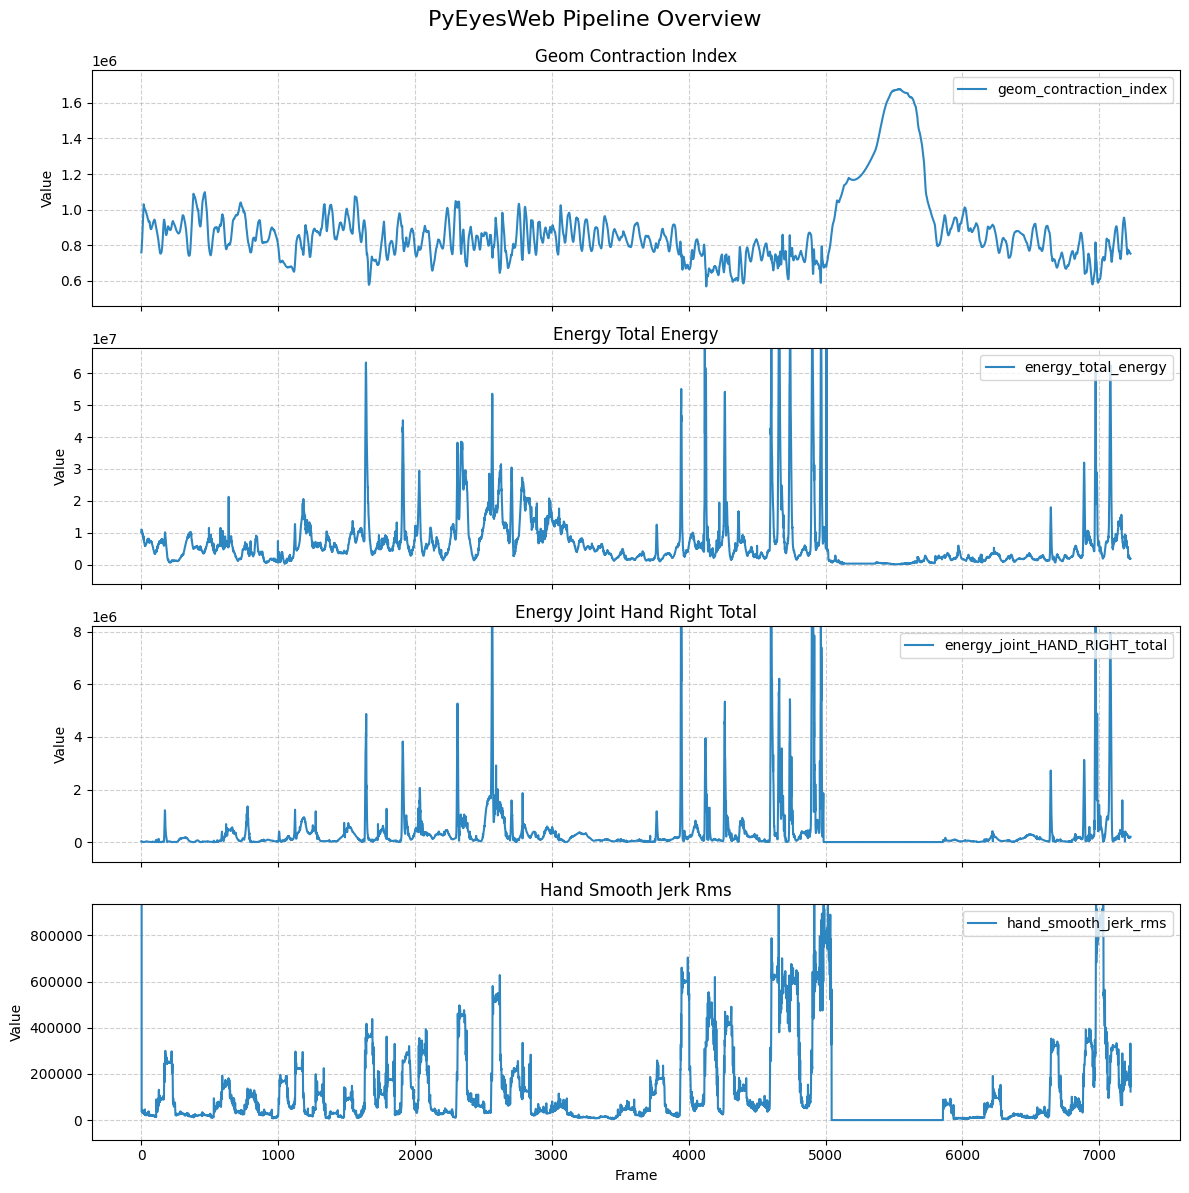

In [10]:
import numpy as np
from tqdm.auto import tqdm

results = []

for pos_frame, vel_frame in tqdm(zip(pos_tensor, vel_tensor), total=len(pos_tensor), desc="Processing Frames"):

    hand_speed = np.linalg.norm(vel_frame[hand_idx])

    # 1. Push new data into the sliding windows
    sw_pos.append(pos_frame)
    sw_vel.append(vel_frame)
    sw_speed.append([[hand_speed]])

    # 2. WAIT FOR THE LONGEST WINDOW TO FILL!
    # By checking the longest window (sw_speed = 60), we ensure all smaller windows are also full.
    if len(sw_speed) < sw_speed.max_length:
        continue  # Skip computation and go to the next frame

    # 3. Compute features and flatten results (This only runs AFTER frame 60)
    res_geom = geom_feature(sw_pos).to_flat_dict("geom")
    res_energy = energy_feature(sw_vel).to_flat_dict("energy")
    res_smooth = smooth_feature(sw_speed).to_flat_dict("hand_smooth")

    # 4. Merge dictionaries and store
    results.append(res_geom | res_energy | res_smooth)

# Plotting
desired_metrics = [
    "geom_contraction_index",
    "energy_total_energy",
    "energy_joint_HAND_RIGHT_total",
    "hand_smooth_jerk_rms"
]

plot_feature_timeseries(
    results_list=results[60:],  # TODO - This is a bit hacky, we should ideally handle the "warm-up" period more elegantly in the future! Features are going out of scale and the plot looks flat
    metrics_to_plot=desired_metrics,
    title="PyEyesWeb Pipeline Overview"
)